In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [60]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Standardization

In [61]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

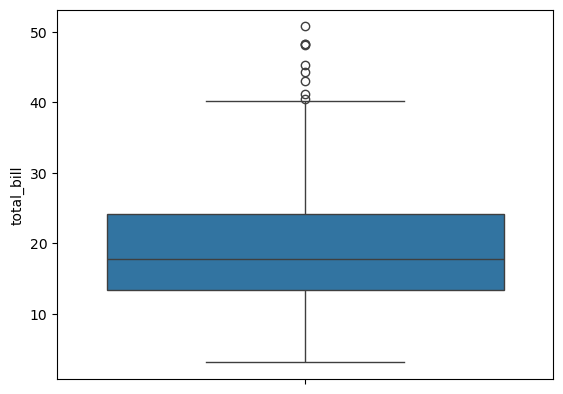

In [62]:
sns.boxplot(df['total_bill'])
plt.show()

In [63]:
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['total_bill'] = df['total_bill'].clip(lower = lower_bound, upper = upper_bound)

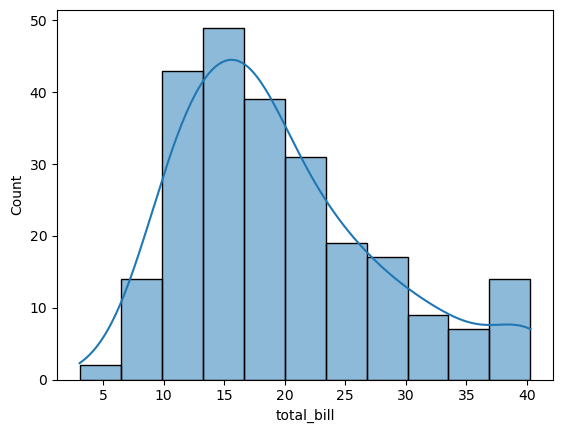

In [64]:
sns.histplot(df['total_bill'], kde = True)
plt.show()

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df.select_dtypes([int, float]))

standerdized_df = pd.DataFrame(
    scaler.transform(df.select_dtypes([int, float])),
    columns = df.select_dtypes([int, float]).columns
)

standerdized_df

,total_bill,tip,size
0,-0.312115,-1.439947,-0.600193
1,-1.109895,-0.969205,0.453383
2,0.170153,0.363356,0.453383
3,0.490465,0.225754,-0.600193
4,0.599635,0.443020,1.506958
...,...,...,...
239,1.132288,2.115963,0.453383
240,0.910349,-0.722971,-0.600193
241,0.369298,-0.722971,-0.600193
242,-0.212542,-0.904026,-0.600193


In [66]:
standerdized_df.mean().round(2)

total_bill   -0.0
tip           0.0
size         -0.0
dtype: float64

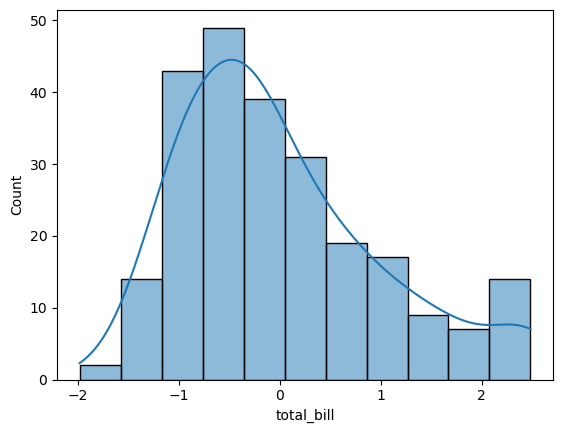

In [67]:
sns.histplot(standerdized_df['total_bill'], kde = True)
plt.show()

# Normalization

### Min-Max Scaling

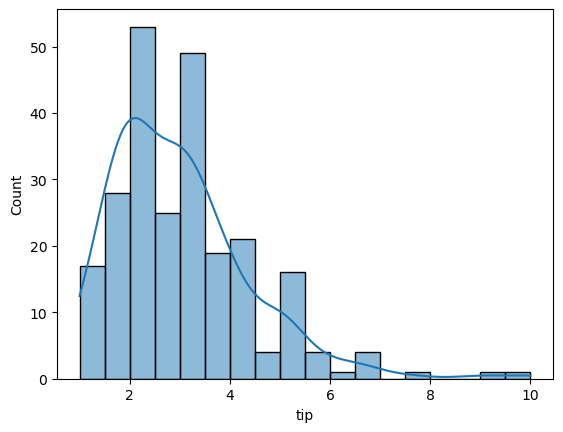

In [68]:
sns.histplot(df['tip'], kde = True)
plt.show()

In [69]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

In [70]:
mms.fit(df.select_dtypes([int, float]))

minmaxscaler_df = pd.DataFrame(
    mms.transform(df.select_dtypes([int, float])),
    columns = df.select_dtypes([int, float]).columns
)

minmaxscaler_df

,total_bill,tip,size
0,0.373917,0.001111,0.2
1,0.195286,0.073333,0.4
2,0.481902,0.277778,0.4
3,0.553623,0.256667,0.2
4,0.578067,0.290000,0.6
...,...,...,...
239,0.697334,0.546667,0.4
240,0.647640,0.111111,0.2
241,0.526493,0.111111,0.2
242,0.396212,0.083333,0.2


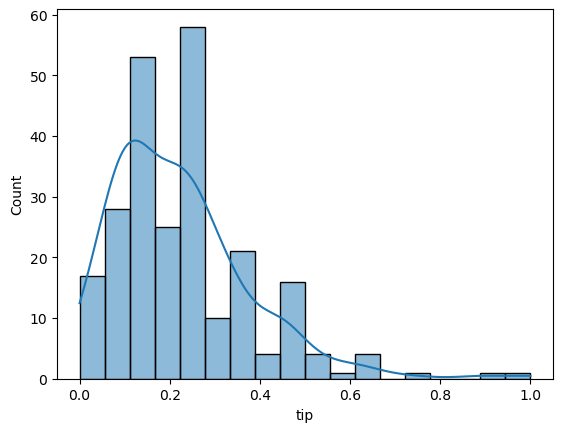

In [71]:
sns.histplot(minmaxscaler_df['tip'], kde = True)
plt.show()